In [37]:
import os
import thinkdsp
import matplotlib.pyplot as plt

# 1. Obtener el directorio actual (donde está ubicado este archivo/notebook)
directorio_actual = os.getcwd()
print(f"Directorio actual del notebook: {directorio_actual}")

# 2. Construir la ruta a la carpeta 'data'
# Nota: Se usa 'data' porque es el nombre real de la carpeta en el disco
ruta_carpeta_datos = os.path.join(directorio_actual, 'data') 

# 3. Definir las rutas completas a los archivos de audio (WAV)
ruta_archivo_a = os.path.join(ruta_carpeta_datos, 'desarrollo_A.wav')
ruta_archivo_b = os.path.join(ruta_carpeta_datos, 'desarrollo_B.wav')

# 4. Verificar que los archivos existen antes de intentar cargarlos
print(f"Buscando archivo A en: {ruta_archivo_a}")
print(f"Buscando archivo B en: {ruta_archivo_b}")

if not os.path.exists(ruta_archivo_a):
    print("\nERROR: Archivo no encontrado. Diagnóstico:")
    print(f"- ¿Existe el directorio 'data'? {os.path.exists(ruta_carpeta_datos)}")
    
    if os.path.exists(ruta_carpeta_datos):
        print(f"- Contenido de la carpeta 'data': {os.listdir(ruta_carpeta_datos)}")
    else:
        print("- El directorio 'data/' NO existe. Debes crearlo y poner los archivos .wav allí.")
    
    # Detener la ejecución con un error claro
    raise FileNotFoundError(f"No se encuentra el archivo: {ruta_archivo_a}")

# 5. Cargar los archivos de audio usando ThinkDSP
onda_audio_a = thinkdsp.read_wave(ruta_archivo_a)
onda_audio_b = thinkdsp.read_wave(ruta_archivo_b)

print("\nArchivos cargados correctamente:")
# Nota: .duration y .framerate son propiedades internas de la librería, no se traducen
print(f"Archivo A: Duración {onda_audio_a.duration:.2f}s, Tasa de muestreo {onda_audio_a.framerate}Hz")
print(f"Archivo B: Duración {onda_audio_b.duration:.2f}s, Tasa de muestreo {onda_audio_b.framerate}Hz")

Directorio actual del notebook: /home/rubengm/Documentos/anacondaName/2025_ASYS_RepositorioPythonSenales/ThinkDSP/code/C2_TP04
Buscando archivo A en: /home/rubengm/Documentos/anacondaName/2025_ASYS_RepositorioPythonSenales/ThinkDSP/code/C2_TP04/data/desarrollo_A.wav
Buscando archivo B en: /home/rubengm/Documentos/anacondaName/2025_ASYS_RepositorioPythonSenales/ThinkDSP/code/C2_TP04/data/desarrollo_B.wav

Archivos cargados correctamente:
Archivo A: Duración 14.86s, Tasa de muestreo 48000Hz
Archivo B: Duración 11.00s, Tasa de muestreo 48000Hz


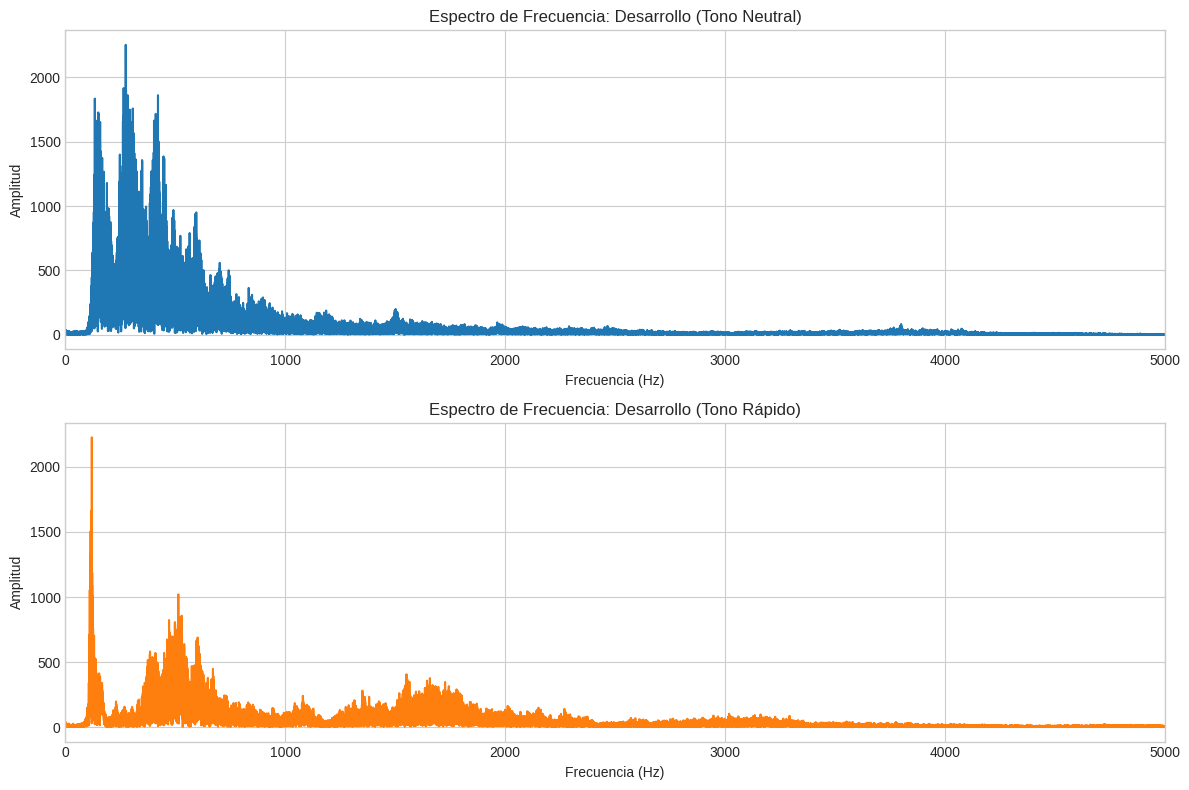

Picos dominantes en A (Frecuencia, Amplitud): [(np.float64(2254.0498079722843), np.float64(274.33340437704015)), (np.float64(1917.0705175306684), np.float64(264.77615623632875)), (np.float64(1903.9166591638864), np.float64(275.7468002288355))]
Picos dominantes en B (Frecuencia, Amplitud): [(np.float64(2227.417676082068), np.float64(120.0909090909091)), (np.float64(1664.7904539222006), np.float64(117.72727272727273)), (np.float64(1614.6177395880643), np.float64(120.27272727272728))]


In [45]:
def graficar_comparacion_espectro(onda1, onda2, titulo1, titulo2):
    # 1. Crear el espectro (Transformada de la onda)
    espectro_a = onda1.make_spectrum()
    espectro_b = onda2.make_spectrum()
    
    plt.figure(figsize=(12, 8))

    # --- Espectro Señal A ---
    plt.subplot(2, 1, 1)
    espectro_a.plot(color='#1f77b4') # Azul
    thinkplot.config(
        xlabel='Frecuencia (Hz)',
        ylabel='Amplitud',
        title=f'Espectro de Frecuencia: {titulo1}',
        xlim=[0, 5000] # Limitamos a 5000Hz porque ahí está la mayor parte de la voz humana
    )

    # --- Espectro Señal B ---
    plt.subplot(2, 1, 2)
    espectro_b.plot(color='#ff7f0e') # Naranja
    thinkplot.config(
        xlabel='Frecuencia (Hz)',
        ylabel='Amplitud',
        title=f'Espectro de Frecuencia: {titulo2}',
        xlim=[0, 5000]
    )
    
    plt.tight_layout()
    plt.show()

    # Imprimir las frecuencias dominantes (Picos)
    print("Picos dominantes en A (Frecuencia, Amplitud):", espectro_a.peaks()[:3])
    print("Picos dominantes en B (Frecuencia, Amplitud):", espectro_b.peaks()[:3])

# Ejecutamos la comparación de espectros
graficar_comparacion_espectro(onda_audio_a, onda_audio_b, "Desarrollo (Tono Neutral)", "Desarrollo (Tono Rápido)")

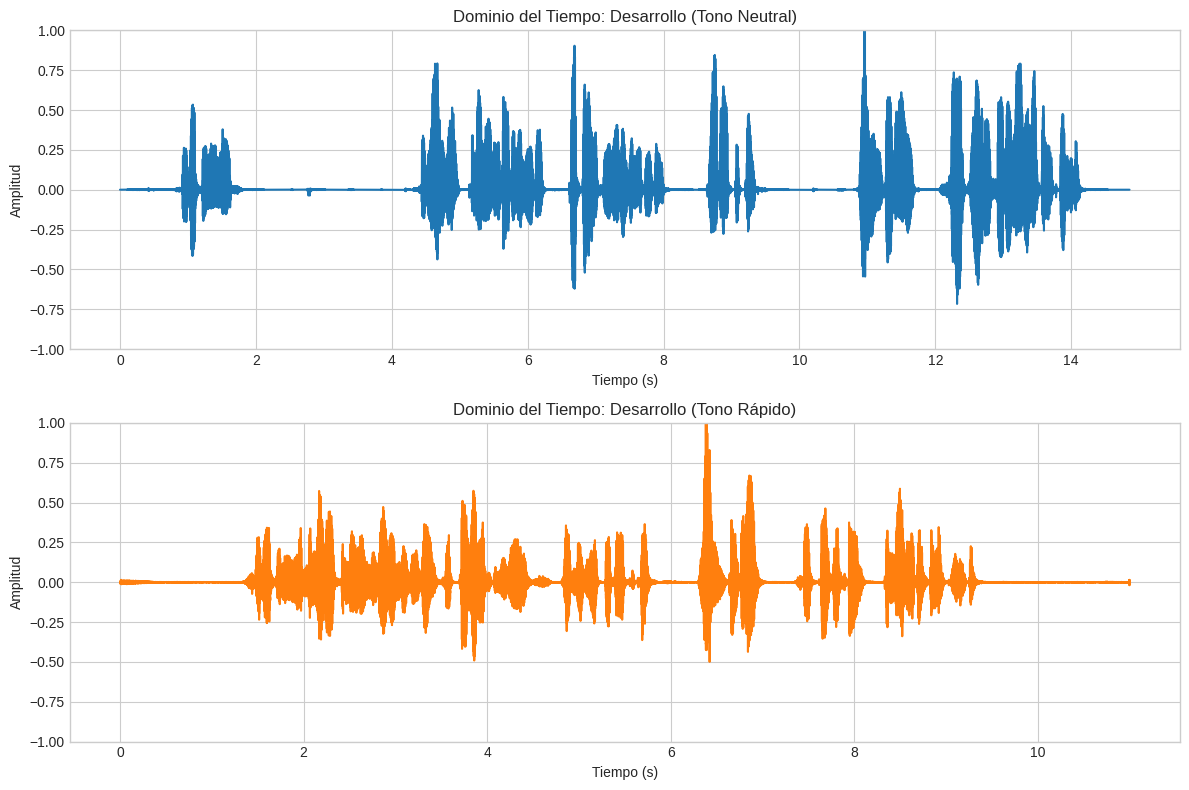

In [43]:
def graficar_comparacion_tiempo(onda1, onda2, titulo1, titulo2):
    plt.figure(figsize=(12, 8))
    
    # --- Gráfica 1: Señal A (Neutral) ---
    plt.subplot(2, 1, 1)
    onda1.plot(color='#1f77b4') # Azul
    thinkplot.config(
        xlabel='Tiempo (s)',
        ylabel='Amplitud',
        title=f'Dominio del Tiempo: {titulo1}',
        ylim=[-1.0, 1.0]
    )
    
    # --- Gráfica 2: Señal B (Rápido/Alto) ---
    plt.subplot(2, 1, 2)
    onda2.plot(color='#ff7f0e') # Naranja
    thinkplot.config(
        xlabel='Tiempo (s)',
        ylabel='Amplitud',
        title=f'Dominio del Tiempo: {titulo2}',
        ylim=[-1.0, 1.0]
    )
    
    plt.tight_layout()
    plt.show()

# Ejecutamos la función con nuestras ondas cargadas
graficar_comparacion_tiempo(onda_audio_a, onda_audio_b, "Desarrollo (Tono Neutral)", "Desarrollo (Tono Rápido)")

ANÁLISIS VECTORIAL: VERSIÓN A (TONO NEUTRAL)


/tmp/ipykernel_11974/3590651413.py:77: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Liberation Sans.
  plt.tight_layout()


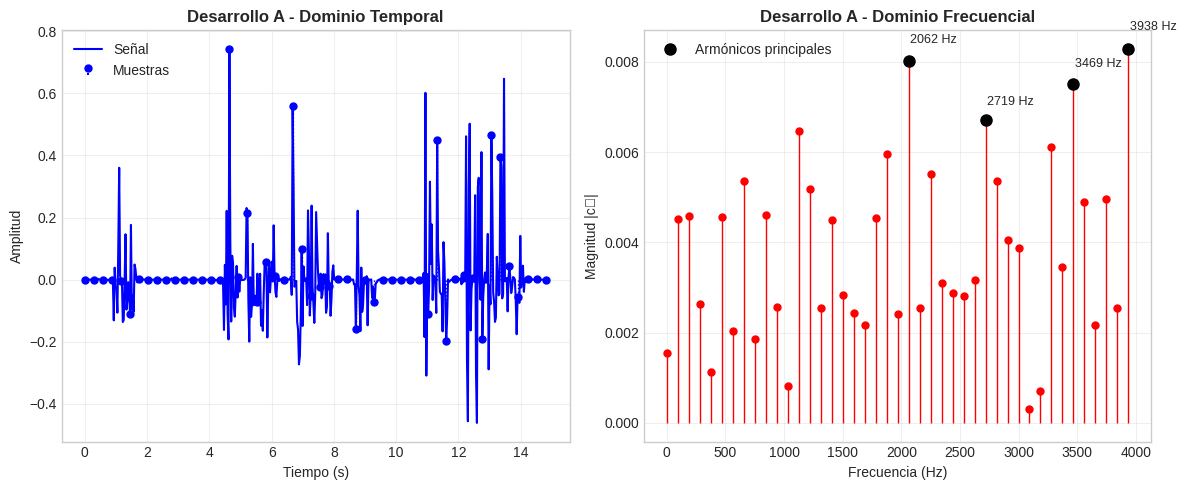


🔊 Desarrollo A (14.86s) - Haga clic para escuchar:



ANÁLISIS VECTORIAL: VERSIÓN B (TONO ALTO)


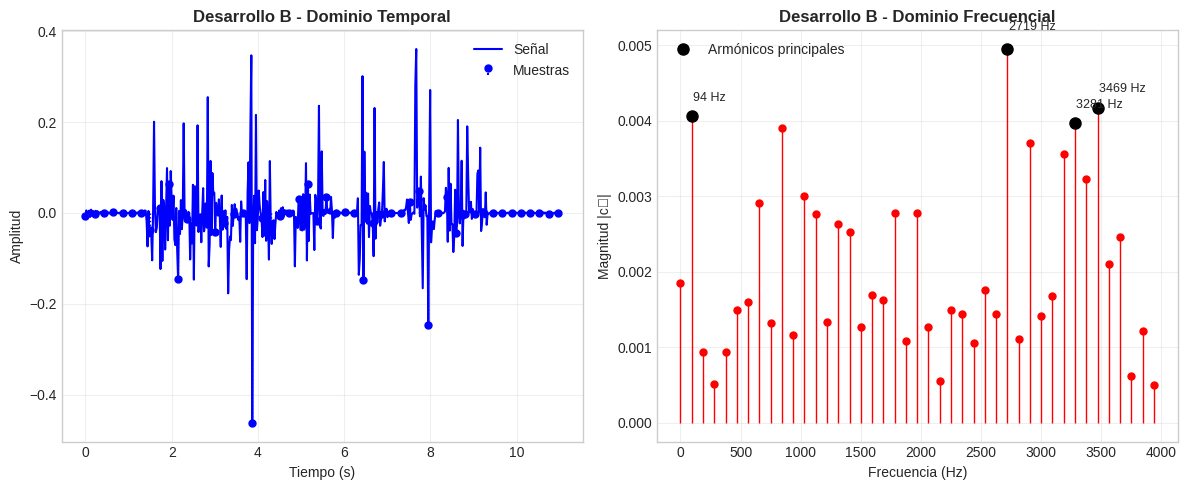


🔊 Desarrollo B (11.00s) - Haga clic para escuchar:


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def analisis_vectorial_señal(wave, titulo="Señal de Voz"):
    """Muestra la representación vectorial de la señal en dominios temporal y frecuencial"""
    
    # 1. Preparar datos vectoriales
    N = 512  # Número óptimo de muestras para visualización clara
    
    # Crear vector de tiempo equiespaciado
    t = np.linspace(0, wave.duration, N, endpoint=False)
    
    # Calcular índices correspondientes en la señal original
    indices = (t * wave.framerate).astype(int)
    # Asegurar que no excedamos el tamaño de la señal
    indices = np.clip(indices, 0, len(wave.ys)-1)
    
    # Obtener valores de la señal en esos puntos
    x = wave.ys[indices]
    
    # 2. Calcular DFT optimizada
    X = np.fft.fft(x) / N
    freqs = np.fft.fftfreq(N, d=1/wave.framerate)
    
    # 3. Visualización eficiente (2 paneles)
    plt.figure(figsize=(12, 5))
    
    # Dominio temporal (vector x)
    plt.subplot(1, 2, 1)
    plt.plot(t, x, 'b-', linewidth=1.5)
    
 
    markerline, stemlines, baseline = plt.stem(t[::10], x[::10], 'b', 
                                             markerfmt='bo', 
                                             basefmt=' ',
                                             linefmt='b:')
    # Personalizar las líneas del stem para mantener el estilo
    plt.setp(stemlines, 'linestyle', ':', 'linewidth', 1)
    plt.setp(markerline, 'markersize', 5)
   
    
    plt.title(f'{titulo} - Dominio Temporal', fontweight='bold')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(alpha=0.3)
    plt.legend(['Señal', 'Muestras'])
    
    # Dominio frecuencial (vector X)
    plt.subplot(1, 2, 2)
    # Solo mostramos frecuencias positivas (0-4000Hz) para voz
    mask = (freqs >= 0) & (freqs <= 4000)
    
   
    markerline, stemlines, baseline = plt.stem(freqs[mask], np.abs(X[mask]), 'r', 
                                             markerfmt='ro', 
                                             basefmt=' ')
    plt.setp(stemlines, 'linewidth', 1)
    plt.setp(markerline, 'markersize', 5)
    
    
    # Resaltar los 4 armónicos principales
    peaks = np.argsort(np.abs(X[mask]))[::-1][:4]
    plt.plot(freqs[mask][peaks], np.abs(X[mask])[peaks], 'ko', markersize=8, 
             label='Armónicos principales')
    
    # Etiquetas de frecuencia
    for i, idx in enumerate(peaks):
        plt.text(freqs[mask][idx] + 10, np.abs(X[mask])[idx] * 1.05, 
                 f'{freqs[mask][idx]:.0f} Hz', fontsize=9)
    
    plt.title(f'{titulo} - Dominio Frecuencial', fontweight='bold')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud |cₙ|')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 4. Reproducción de audio integrada
    print(f"\n🔊 {titulo} ({wave.duration:.2f}s) - Haga clic para escuchar:")
    display(Audio(wave.ys, rate=wave.framerate))

# Ejecutar análisis para ambas versiones
print("="*50)
print("ANÁLISIS VECTORIAL: VERSIÓN A (TONO NEUTRAL)")
print("="*50)
analisis_vectorial_señal(wave_a, "Desarrollo A")

print("\n" + "="*50)
print("ANÁLISIS VECTORIAL: VERSIÓN B (TONO ALTO)")
print("="*50)
analisis_vectorial_señal(wave_b, "Desarrollo B")